In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00484_2.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00541_4.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00305_0.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00052_2.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00218_2.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00353_0.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00013_3.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00093_0.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00559_4.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00518_0.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00554_0.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/images/00333_1.jpg
/kaggle/input/datasets/harsh83022/leaves/aug_data/aug_data/image

In [2]:
!pip install torch==2.4.1+cu118 torchvision==0.19.1+cu118 torchaudio==2.4.1+cu118 \
--index-url https://download.pytorch.org/whl/cu118 -q

In [3]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.4.1+cu118
11.8
Tesla P100-PCIE-16GB


In [4]:
import torch

x = torch.rand(2,2).cuda()

print(x)

tensor([[0.1607, 0.5992],
        [0.0759, 0.6866]], device='cuda:0')


Using Device: cuda
Total Samples: 3528
Train: 2822
Val: 706


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Model Loaded Successfully
✅ Best Model Saved!

Epoch [1/20]
Train Loss : 0.4728
Train Dice : 0.5846
Val Loss   : 0.4280
Val Dice   : 0.6114
✅ Best Model Saved!

Epoch [2/20]
Train Loss : 0.3826
Train Dice : 0.6384
Val Loss   : 0.3674
Val Dice   : 0.6507
✅ Best Model Saved!

Epoch [3/20]
Train Loss : 0.3423
Train Dice : 0.6660
Val Loss   : 0.3459
Val Dice   : 0.6673
✅ Best Model Saved!

Epoch [4/20]
Train Loss : 0.3181
Train Dice : 0.6849
Val Loss   : 0.2985
Val Dice   : 0.6984
✅ Best Model Saved!

Epoch [5/20]
Train Loss : 0.2966
Train Dice : 0.7057
Val Loss   : 0.2794
Val Dice   : 0.7268
✅ Best Model Saved!

Epoch [6/20]
Train Loss : 0.2777
Train Dice : 0.7246
Val Loss   : 0.2567
Val Dice   : 0.7443

Epoch [7/20]
Train Loss : 0.2629
Train Dice : 0.7377
Val Loss   : 0.2766
Val Dice   : 0.7152
✅ Best Model Saved!

Epoch [8/20]
Train Loss : 0.2593
Train Dice : 0.7413
Val Loss   : 0.2384
Val Dice   : 0.7607
✅ Best Model Saved!

Epoch [9/20]
Train Loss : 0.2511
Train Dice : 0.7483
Val Loss

/tmp/ipykernel_127/2383395275.py:611: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


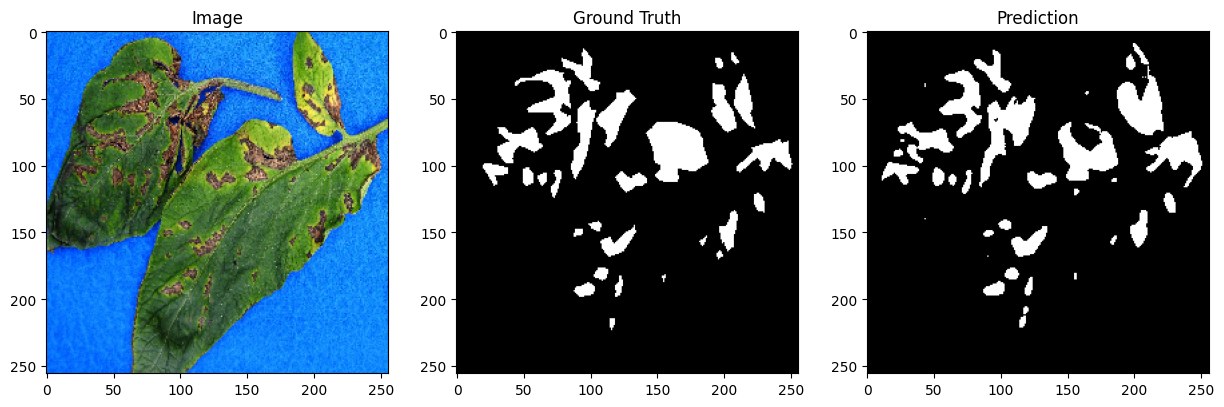

In [5]:
# =========================================================
# LEAF SEGMENTATION USING U-NET (FROM SCRATCH)
# =========================================================

# ================= INSTALL ================= #

!pip install -q albumentations


# ================= IMPORTS ================= #

import os
import cv2
import torch
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


# ================= DEVICE ================= #

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)


# ================= PATHS ================= #

DATASET_PATH = "/kaggle/input/datasets/harsh83022/leaves"

orig_img = f"{DATASET_PATH}/data/data/images"
orig_mask = f"{DATASET_PATH}/data/data/masks"

aug_img = f"{DATASET_PATH}/aug_data/aug_data/images"
aug_mask = f"{DATASET_PATH}/aug_data/aug_data/masks"


# ================= IMAGE-MASK PAIRS ================= #

def get_pairs(img_dir, mask_dir):

    image_paths = []
    mask_paths = []

    mask_dict = {

        os.path.splitext(m)[0]:
        os.path.join(mask_dir, m)

        for m in os.listdir(mask_dir)
    }

    for img in os.listdir(img_dir):

        key = os.path.splitext(img)[0]

        if key in mask_dict:

            image_paths.append(
                os.path.join(img_dir, img)
            )

            mask_paths.append(
                mask_dict[key]
            )

    return image_paths, mask_paths


img1, mask1 = get_pairs(orig_img, orig_mask)
img2, mask2 = get_pairs(aug_img, aug_mask)

image_paths = img1 + img2
mask_paths = mask1 + mask2

print("Total Samples:", len(image_paths))


# ================= TRAIN VAL SPLIT ================= #

train_img, val_img, train_mask, val_mask = train_test_split(

    image_paths,
    mask_paths,

    test_size=0.2,

    random_state=42

)

print("Train:", len(train_img))
print("Val:", len(val_img))


# ================= AUGMENTATION ================= #

train_transform = A.Compose([

    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(

        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=20,

        p=0.5

    ),

    A.RandomBrightnessContrast(p=0.3),

])

val_transform = A.Compose([

    A.Resize(256, 256)

])


# ================= DATASET ================= #

class LeafDataset(Dataset):

    def __init__(self, images, masks, transform=None):

        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # IMAGE
        img = cv2.imread(self.images[idx])

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # MASK
        mask = cv2.imread(
            self.masks[idx],
            0
        )

        # BINARY MASK
        mask = (mask > 0).astype("float32")

        # AUGMENTATION
        if self.transform:

            augmented = self.transform(

                image=img,
                mask=mask

            )

            img = augmented["image"]
            mask = augmented["mask"]

        # NORMALIZATION
        img = img / 255.0

        # TENSOR
        img = torch.tensor(img).permute(2,0,1).float()

        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask


# ================= DATALOADER ================= #

train_dataset = LeafDataset(

    train_img,
    train_mask,

    train_transform

)

val_dataset = LeafDataset(

    val_img,
    val_mask,

    val_transform

)

train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)


# =========================================================
# U-NET MODEL FROM SCRATCH
# =========================================================

def double_conv(in_c, out_c):

    return nn.Sequential(

        nn.Conv2d(
            in_c,
            out_c,
            kernel_size=3,
            padding=1
        ),

        nn.BatchNorm2d(out_c),

        nn.ReLU(inplace=True),

        nn.Conv2d(
            out_c,
            out_c,
            kernel_size=3,
            padding=1
        ),

        nn.BatchNorm2d(out_c),

        nn.ReLU(inplace=True)

    )


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ENCODER

        self.enc1 = double_conv(3, 64)

        self.enc2 = double_conv(64, 128)

        self.enc3 = double_conv(128, 256)

        self.enc4 = double_conv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # BOTTLENECK

        self.bottleneck = double_conv(512, 1024)

        # DECODER

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = double_conv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = double_conv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = double_conv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = double_conv(128, 64)

        # OUTPUT

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # ENCODER

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # BOTTLENECK

        b = self.bottleneck(
            self.pool(e4)
        )

        # DECODER

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        # OUTPUT

        out = torch.sigmoid(
            self.final(d1)
        )

        return out


# ================= MODEL ================= #

model = UNet().to(device)

print("Model Loaded Successfully")


# ================= LOSS ================= #

def dice_loss(pred, target):

    smooth = 1e-8

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    dice = (

        2. * intersection + smooth

    ) / (

        pred.sum() + target.sum() + smooth

    )

    return 1 - dice


bce_loss = nn.BCELoss()


def loss_fn(pred, target):

    return (

        0.5 * bce_loss(pred, target)

        +

        0.5 * dice_loss(pred, target)

    )


# ================= METRIC ================= #

def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    return (

        2. * intersection

    ) / (

        pred.sum() + target.sum() + 1e-8

    )


# ================= OPTIMIZER ================= #

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4

)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='max',

    patience=2,

    factor=0.5

)


# =========================================================
# TRAINING
# =========================================================

epochs = 20

best_dice = 0

for epoch in range(epochs):

    # ================= TRAIN ================= #

    model.train()

    train_loss = 0
    train_dice = 0

    for img, mask in train_loader:

        img = img.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        # FORWARD
        pred = model(img)

        loss = loss_fn(pred, mask)

        # BACKWARD
        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_dice += dice_score(
            pred,
            mask
        ).item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    # ================= VALIDATION ================= #

    model.eval()

    val_loss = 0
    val_dice = 0

    with torch.no_grad():

        for img, mask in val_loader:

            img = img.to(device)
            mask = mask.to(device)

            pred = model(img)

            loss = loss_fn(pred, mask)

            val_loss += loss.item()

            val_dice += dice_score(
                pred,
                mask
            ).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    scheduler.step(val_dice)

    # ================= SAVE BEST MODEL ================= #

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(

            model.state_dict(),

            "/kaggle/working/best_leaf_segmentation.pth"

        )

        print("✅ Best Model Saved!")

    # ================= PRINT ================= #

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")


# =========================================================
# LOAD BEST MODEL
# =========================================================

model.load_state_dict(

    torch.load(
        "/kaggle/working/best_leaf_segmentation.pth"
    )

)

print("\n✅ Best Model Loaded!")


# =========================================================
# VISUALIZATION
# =========================================================

model.eval()

img, mask = val_dataset[10]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.5).astype(np.uint8)

img = img.permute(1,2,0).numpy()

plt.figure(figsize=(15,5))

# IMAGE
plt.subplot(1,3,1)

plt.imshow(img)

plt.title("Image")

# MASK
plt.subplot(1,3,2)

plt.imshow(
    mask.squeeze(),
    cmap='gray'
)

plt.title("Ground Truth")

# PREDICTION
plt.subplot(1,3,3)

plt.imshow(
    pred,
    cmap='gray'
)

plt.title("Prediction")

plt.show()

Using Device: cuda
Total Samples: 3528
Train: 2822
Val: 706


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Model Loaded Successfully
✅ Previous Best Model Loaded!


/tmp/ipykernel_127/2149982975.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


✅ New Best Model Saved!

Epoch [1/20]
Train Loss : 0.1819
Train Dice : 0.8201
Val Loss   : 0.1578
Val Dice   : 0.8460
✅ New Best Model Saved!

Epoch [2/20]
Train Loss : 0.1771
Train Dice : 0.8238
Val Loss   : 0.1532
Val Dice   : 0.8478

Epoch [3/20]
Train Loss : 0.1745
Train Dice : 0.8250
Val Loss   : 0.1542
Val Dice   : 0.8430
✅ New Best Model Saved!

Epoch [4/20]
Train Loss : 0.1704
Train Dice : 0.8294
Val Loss   : 0.1522
Val Dice   : 0.8528

Epoch [5/20]
Train Loss : 0.1673
Train Dice : 0.8322
Val Loss   : 0.1535
Val Dice   : 0.8407
✅ New Best Model Saved!

Epoch [6/20]
Train Loss : 0.1636
Train Dice : 0.8361
Val Loss   : 0.1524
Val Dice   : 0.8551

Epoch [7/20]
Train Loss : 0.1631
Train Dice : 0.8358
Val Loss   : 0.1460
Val Dice   : 0.8509
✅ New Best Model Saved!

Epoch [8/20]
Train Loss : 0.1628
Train Dice : 0.8357
Val Loss   : 0.1419
Val Dice   : 0.8559
✅ New Best Model Saved!

Epoch [9/20]
Train Loss : 0.1581
Train Dice : 0.8410
Val Loss   : 0.1426
Val Dice   : 0.8616

Epoch [10

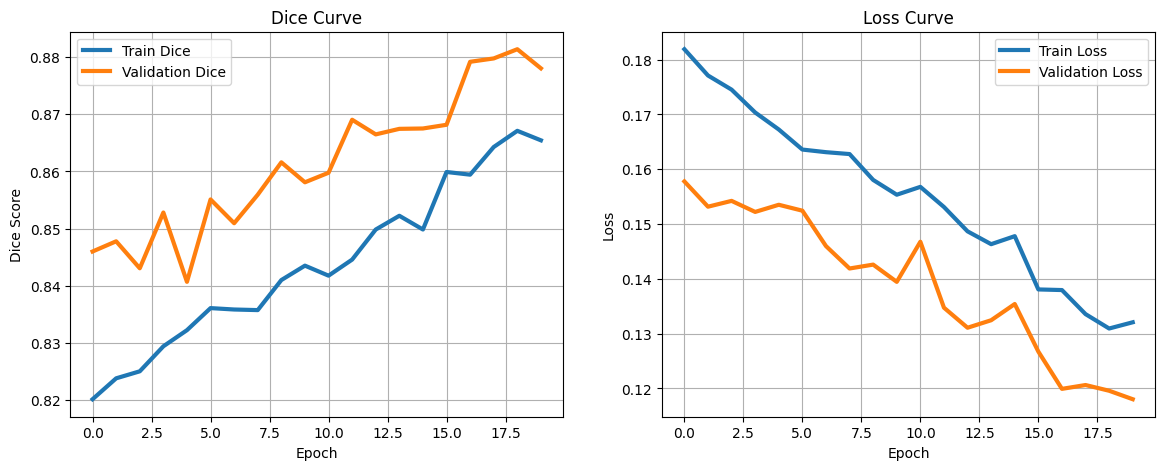

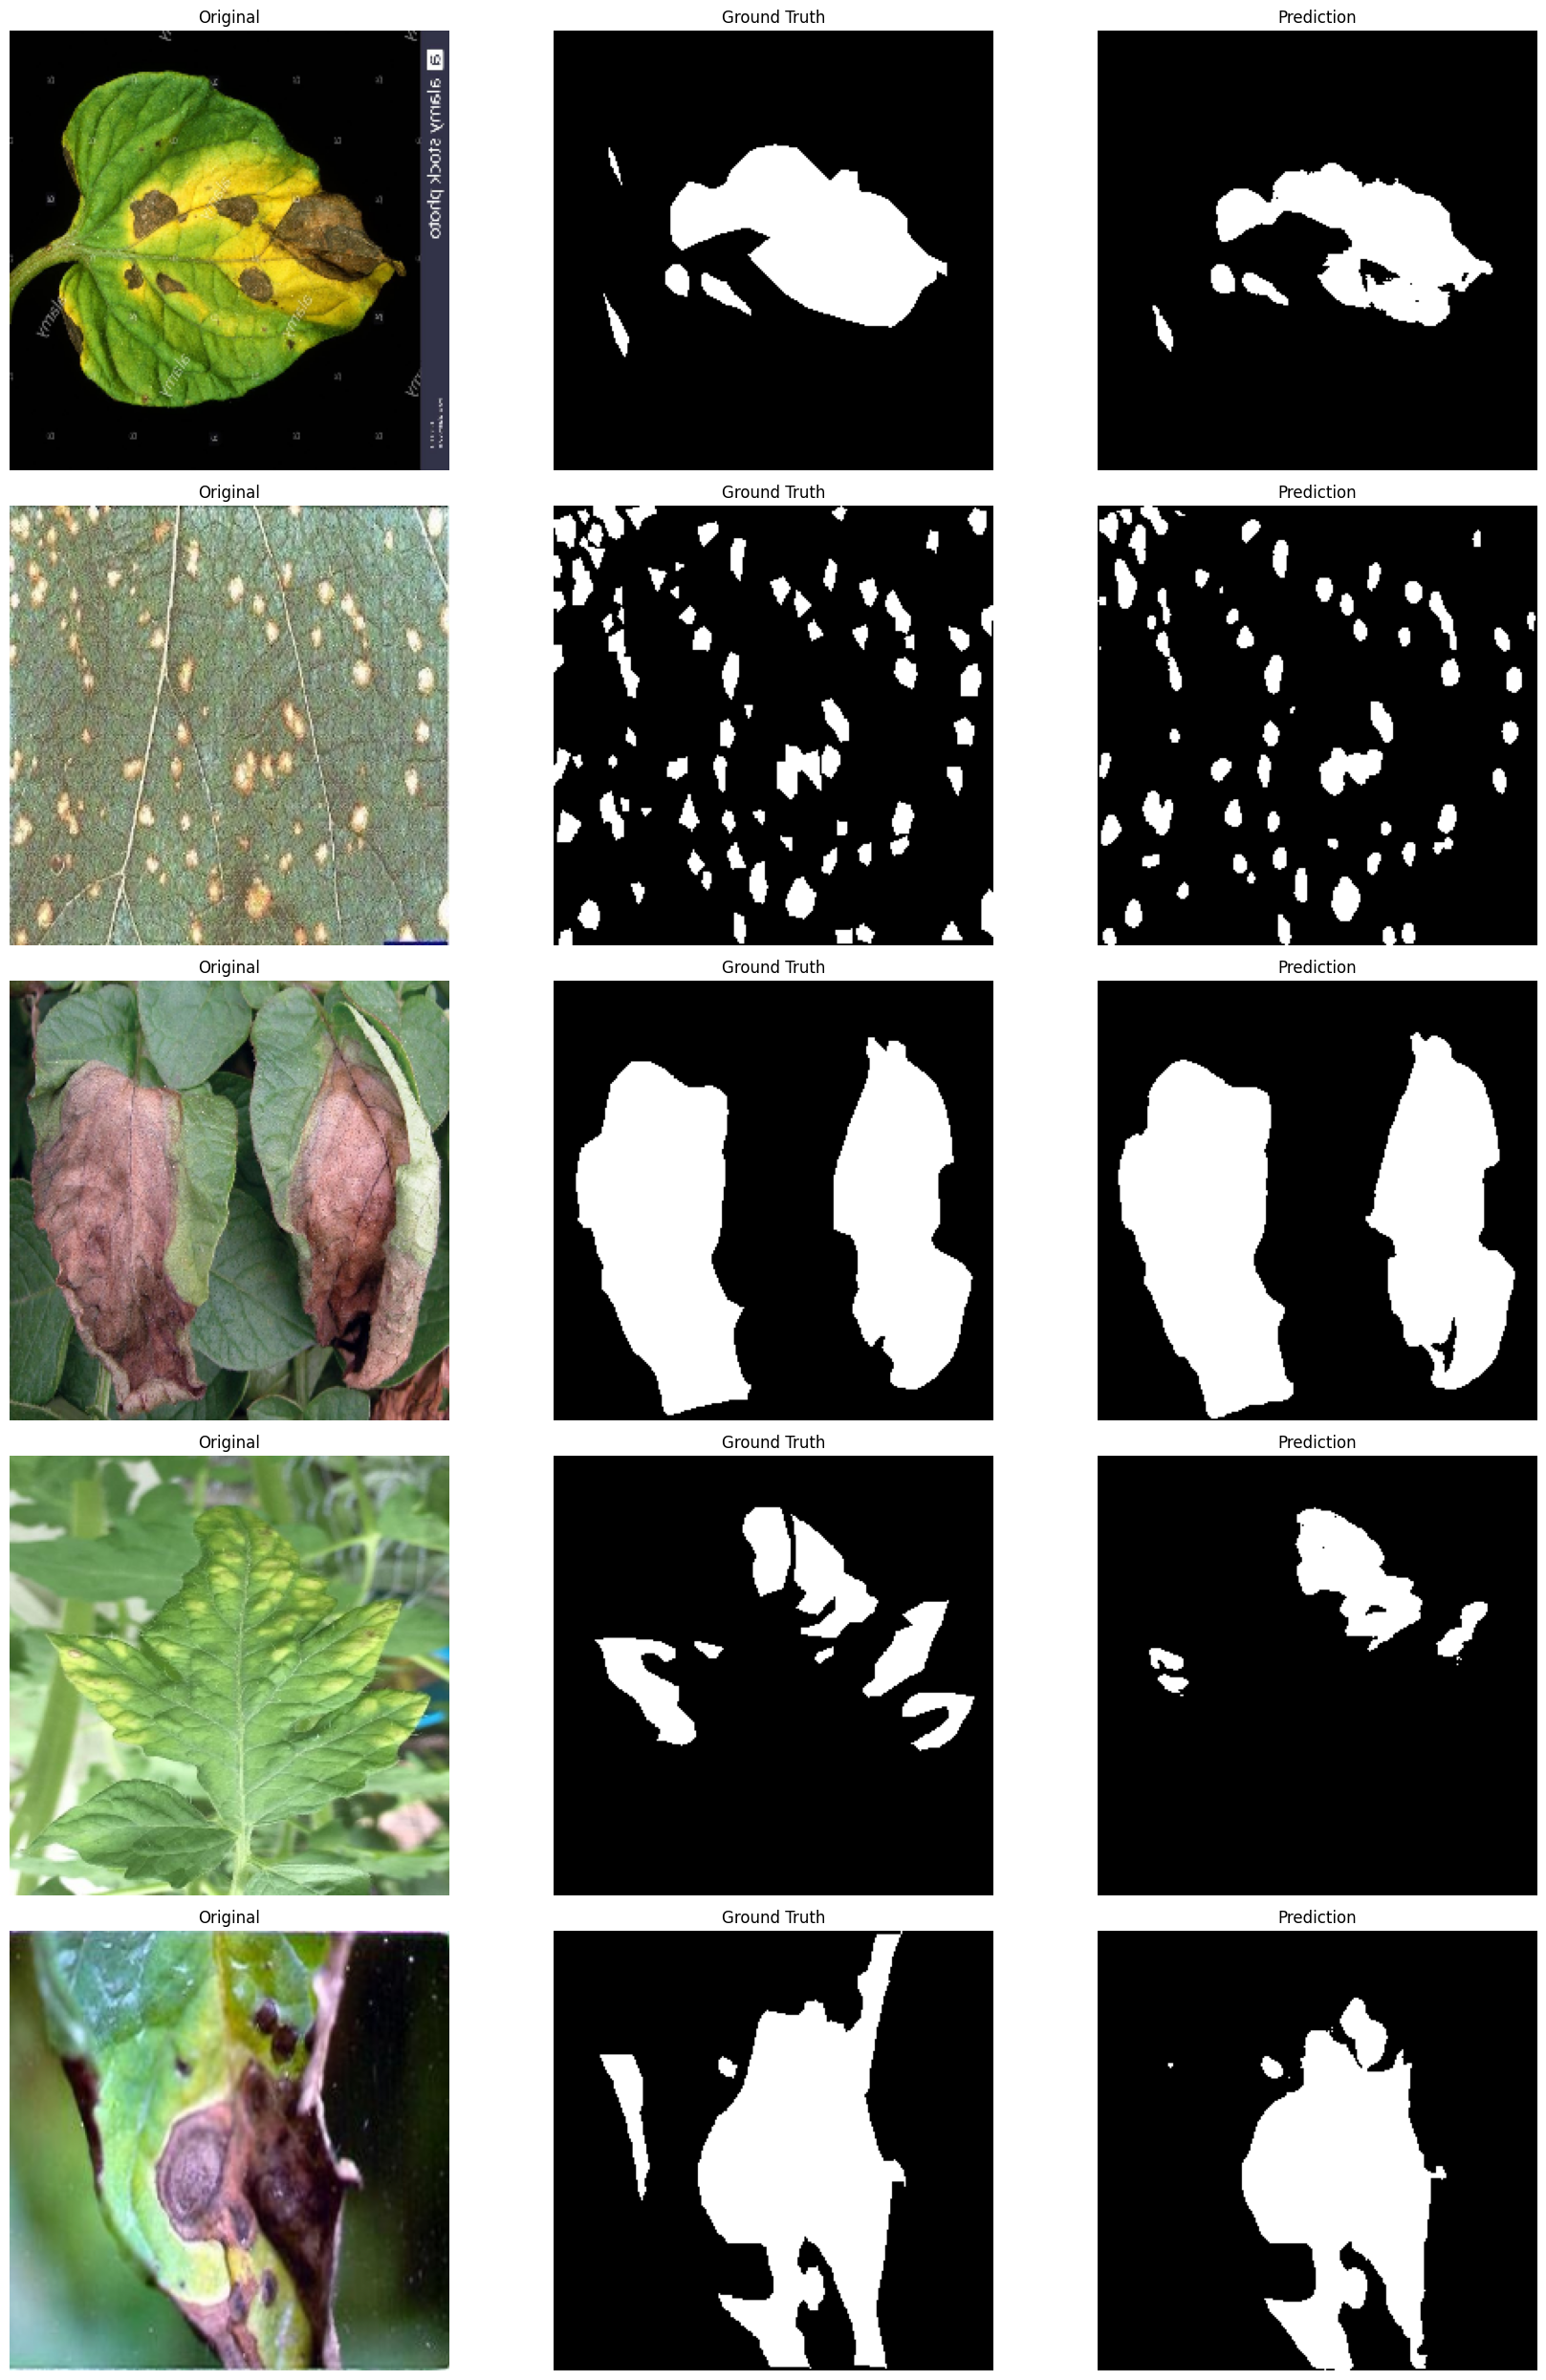

In [7]:
# =========================================================
# LEAF SEGMENTATION USING U-NET (CONTINUE TRAINING)
# =========================================================

# ================= INSTALL ================= #

!pip install -q albumentations


# ================= IMPORTS ================= #

import os
import cv2
import torch
import random
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


# ================= DEVICE ================= #

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)


# ================= PATHS ================= #

DATASET_PATH = "/kaggle/input/datasets/harsh83022/leaves"

orig_img = f"{DATASET_PATH}/data/data/images"
orig_mask = f"{DATASET_PATH}/data/data/masks"

aug_img = f"{DATASET_PATH}/aug_data/aug_data/images"
aug_mask = f"{DATASET_PATH}/aug_data/aug_data/masks"


# ================= IMAGE MASK PAIRS ================= #

def get_pairs(img_dir, mask_dir):

    image_paths = []
    mask_paths = []

    mask_dict = {

        os.path.splitext(m)[0]:
        os.path.join(mask_dir, m)

        for m in os.listdir(mask_dir)
    }

    for img in os.listdir(img_dir):

        key = os.path.splitext(img)[0]

        if key in mask_dict:

            image_paths.append(
                os.path.join(img_dir, img)
            )

            mask_paths.append(
                mask_dict[key]
            )

    return image_paths, mask_paths


img1, mask1 = get_pairs(orig_img, orig_mask)
img2, mask2 = get_pairs(aug_img, aug_mask)

image_paths = img1 + img2
mask_paths = mask1 + mask2

print("Total Samples:", len(image_paths))


# ================= TRAIN VAL SPLIT ================= #

train_img, val_img, train_mask, val_mask = train_test_split(

    image_paths,
    mask_paths,

    test_size=0.2,

    random_state=42

)

print("Train:", len(train_img))
print("Val:", len(val_img))


# ================= AUGMENTATION ================= #

train_transform = A.Compose([

    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(

        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=20,

        p=0.5

    ),

    A.RandomBrightnessContrast(p=0.3),

])

val_transform = A.Compose([

    A.Resize(256, 256)

])


# ================= DATASET ================= #

class LeafDataset(Dataset):

    def __init__(self, images, masks, transform=None):

        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # IMAGE
        img = cv2.imread(self.images[idx])

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # MASK
        mask = cv2.imread(
            self.masks[idx],
            0
        )

        mask = (mask > 0).astype("float32")

        # AUGMENTATION
        if self.transform:

            augmented = self.transform(

                image=img,
                mask=mask

            )

            img = augmented["image"]
            mask = augmented["mask"]

        # NORMALIZATION
        img = img / 255.0

        # TO TENSOR
        img = torch.tensor(img).permute(2,0,1).float()

        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask


# ================= DATALOADER ================= #

train_dataset = LeafDataset(

    train_img,
    train_mask,

    train_transform

)

val_dataset = LeafDataset(

    val_img,
    val_mask,

    val_transform

)

train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)


# =========================================================
# U-NET MODEL
# =========================================================

def double_conv(in_c, out_c):

    return nn.Sequential(

        nn.Conv2d(
            in_c,
            out_c,
            3,
            padding=1
        ),

        nn.BatchNorm2d(out_c),

        nn.ReLU(inplace=True),

        nn.Conv2d(
            out_c,
            out_c,
            3,
            padding=1
        ),

        nn.BatchNorm2d(out_c),

        nn.ReLU(inplace=True)

    )


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ENCODER

        self.enc1 = double_conv(3, 64)

        self.enc2 = double_conv(64, 128)

        self.enc3 = double_conv(128, 256)

        self.enc4 = double_conv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # BOTTLENECK

        self.bottleneck = double_conv(512, 1024)

        # DECODER

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            2,
            stride=2
        )

        self.dec4 = double_conv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            2,
            stride=2
        )

        self.dec3 = double_conv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.dec2 = double_conv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.dec1 = double_conv(128, 64)

        # OUTPUT

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # ENCODER

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # BOTTLENECK

        b = self.bottleneck(
            self.pool(e4)
        )

        # DECODER

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        out = torch.sigmoid(
            self.final(d1)
        )

        return out


# ================= MODEL ================= #

model = UNet().to(device)

print("Model Loaded Successfully")


# =========================================================
# LOAD PREVIOUS BEST MODEL
# =========================================================

model.load_state_dict(

    torch.load(
        "/kaggle/working/best_leaf_segmentation.pth"
    )

)

print("✅ Previous Best Model Loaded!")


# =========================================================
# TVERSKY LOSS
# =========================================================

def tversky_loss(
    pred,
    target,
    alpha=0.7,
    beta=0.3
):

    smooth = 1e-8

    pred = pred.view(-1)
    target = target.view(-1)

    TP = (pred * target).sum()

    FP = ((1 - target) * pred).sum()

    FN = (target * (1 - pred)).sum()

    tversky = (

        TP + smooth

    ) / (

        TP + alpha * FP + beta * FN + smooth

    )

    return 1 - tversky


# ================= BCE ================= #

bce_loss = nn.BCELoss()


# ================= FINAL LOSS ================= #

def loss_fn(pred, target):

    return (

        0.3 * bce_loss(pred, target)

        +

        0.7 * tversky_loss(pred, target)

    )


# ================= DICE SCORE ================= #

def dice_score(pred, target):

    pred = (pred > 0.4).float()

    intersection = (pred * target).sum()

    return (

        2. * intersection

    ) / (

        pred.sum() + target.sum() + 1e-8

    )


# ================= IOU ================= #

def iou_score(pred, target):

    pred = (pred > 0.4).float()

    intersection = (pred * target).sum()

    union = (
        pred + target
    ).sum() - intersection

    return (

        intersection + 1e-8

    ) / (

        union + 1e-8

    )


# ================= OPTIMIZER ================= #

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=5e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='max',

    patience=2,

    factor=0.5

)


# =========================================================
# METRIC LISTS
# =========================================================

train_loss_list = []
val_loss_list = []

train_dice_list = []
val_dice_list = []


# =========================================================
# CONTINUE TRAINING
# =========================================================

epochs = 20

best_dice = 0.8319


for epoch in range(epochs):

    # ================= TRAIN ================= #

    model.train()

    train_loss = 0
    train_dice = 0

    for img, mask in train_loader:

        img = img.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        pred = model(img)

        loss = loss_fn(pred, mask)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_dice += dice_score(
            pred,
            mask
        ).item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    train_loss_list.append(train_loss)
    train_dice_list.append(train_dice)

    # ================= VALIDATION ================= #

    model.eval()

    val_loss = 0
    val_dice = 0

    with torch.no_grad():

        for img, mask in val_loader:

            img = img.to(device)
            mask = mask.to(device)

            pred = model(img)

            loss = loss_fn(pred, mask)

            val_loss += loss.item()

            val_dice += dice_score(
                pred,
                mask
            ).item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    val_loss_list.append(val_loss)
    val_dice_list.append(val_dice)

    scheduler.step(val_dice)

    # ================= SAVE BEST MODEL ================= #

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(

            model.state_dict(),

            "/kaggle/working/best_leaf_segmentation_v2.pth"

        )

        print("✅ New Best Model Saved!")

    # ================= PRINT ================= #

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")


# =========================================================
# FINAL IOU SCORE
# =========================================================

iou_total = 0

model.eval()

with torch.no_grad():

    for img, mask in val_loader:

        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        iou_total += iou_score(
            pred,
            mask
        ).item()

mean_iou = iou_total / len(val_loader)

print(f"\n✅ Final Mean IoU : {mean_iou:.4f}")


# =========================================================
# TRAINING CURVES
# =========================================================

plt.figure(figsize=(14,5))

# DICE
plt.subplot(1,2,1)

plt.plot(
    train_dice_list,
    label="Train Dice",
    linewidth=3
)

plt.plot(
    val_dice_list,
    label="Validation Dice",
    linewidth=3
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")

plt.title("Dice Curve")

plt.legend()

plt.grid(True)

# LOSS
plt.subplot(1,2,2)

plt.plot(
    train_loss_list,
    label="Train Loss",
    linewidth=3
)

plt.plot(
    val_loss_list,
    label="Validation Loss",
    linewidth=3
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid(True)

plt.show()


# =========================================================
# RANDOM PREDICTIONS
# =========================================================

model.eval()

num_samples = 5

random_indices = random.sample(
    range(len(val_dataset)),
    num_samples
)

plt.figure(figsize=(18, num_samples * 5))

for i, idx in enumerate(random_indices):

    img, mask = val_dataset[idx]

    with torch.no_grad():

        pred = model(
            img.unsqueeze(0).to(device)
        )

    pred = pred.squeeze().cpu().numpy()

    pred = (pred > 0.4).astype(np.uint8)

    image = img.permute(1,2,0).numpy()

    # ORIGINAL
    plt.subplot(num_samples,3,i*3+1)

    plt.imshow(image)

    plt.title("Original")

    plt.axis("off")

    # GT
    plt.subplot(num_samples,3,i*3+2)

    plt.imshow(
        mask.squeeze(),
        cmap='gray'
    )

    plt.title("Ground Truth")

    plt.axis("off")

    # PREDICTION
    plt.subplot(num_samples,3,i*3+3)

    plt.imshow(
        pred,
        cmap='gray'
    )

    plt.title("Prediction")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
# =========================================================
# SAVE PREDICTIONS
# =========================================================

import os

save_dir = "/kaggle/working/final_predictions"

os.makedirs(save_dir, exist_ok=True)

model.eval()

for idx in range(20):

    img, mask = val_dataset[idx]

    with torch.no_grad():

        pred = model(
            img.unsqueeze(0).to(device)
        )

    pred = pred.squeeze().cpu().numpy()

    pred = (pred > 0.4).astype(np.uint8) * 255

    image = img.permute(1,2,0).numpy()

    image = (image * 255).astype(np.uint8)

    # SAVE ORIGINAL
    cv2.imwrite(
        f"{save_dir}/image_{idx}.png",
        cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    )

    # SAVE MASK
    cv2.imwrite(
        f"{save_dir}/mask_{idx}.png",
        mask.squeeze().numpy() * 255
    )

    # SAVE PREDICTION
    cv2.imwrite(
        f"{save_dir}/pred_{idx}.png",
        pred
    )

print("✅ Predictions Saved!")

[ WARN:0@5001.466] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


✅ Predictions Saved!


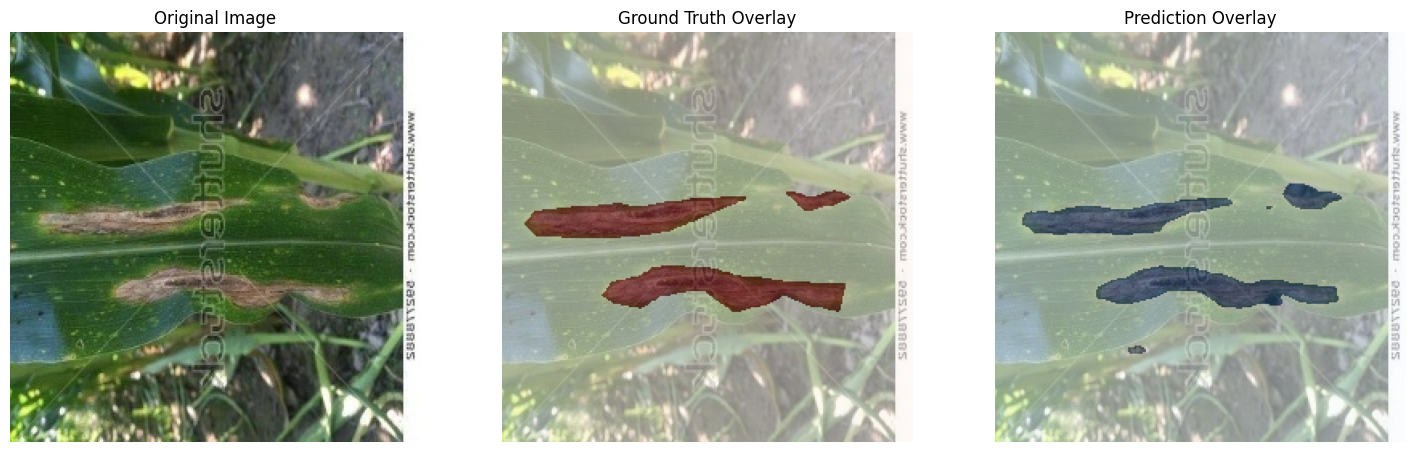

In [9]:
# =========================================================
# OVERLAY VISUALIZATION
# =========================================================

model.eval()

img, mask = val_dataset[15]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.4).astype(np.uint8)

image = img.permute(1,2,0).numpy()

plt.figure(figsize=(18,6))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")

# GROUND TRUTH
plt.subplot(1,3,2)

plt.imshow(image)

plt.imshow(
    mask.squeeze(),
    cmap='Reds',
    alpha=0.5
)

plt.title("Ground Truth Overlay")

plt.axis("off")

# PREDICTION
plt.subplot(1,3,3)

plt.imshow(image)

plt.imshow(
    pred,
    cmap='Blues',
    alpha=0.5
)

plt.title("Prediction Overlay")

plt.axis("off")

plt.show()

In [10]:
# =========================================================
# FINAL METRICS
# =========================================================

def pixel_accuracy(pred, target):

    pred = (pred > 0.4).float()

    correct = (pred == target).float().sum()

    total = torch.numel(pred)

    return correct / total


accuracy_total = 0

model.eval()

with torch.no_grad():

    for img, mask in val_loader:

        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        accuracy_total += pixel_accuracy(
            pred,
            mask
        ).item()

mean_accuracy = accuracy_total / len(val_loader)

print(f"✅ Pixel Accuracy : {mean_accuracy:.4f}")

✅ Pixel Accuracy : 0.9637


In [11]:
# =========================================================
# DISEASE SEVERITY ESTIMATION
# =========================================================

img, mask = val_dataset[10]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.4).astype(np.uint8)

# DISEASE PIXELS
disease_pixels = np.sum(pred)

# TOTAL PIXELS
total_pixels = pred.shape[0] * pred.shape[1]

# PERCENTAGE
severity = (
    disease_pixels / total_pixels
) * 100

print(f"Disease Severity : {severity:.2f}%")

Disease Severity : 10.18%


In [12]:
# =========================================================
# IMPROVED DISEASE SEVERITY
# =========================================================

img, mask = val_dataset[10]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.4).astype(np.uint8)

# DISEASE PIXELS
disease_pixels = np.sum(pred)

# LEAF PIXELS
leaf_pixels = np.sum(mask.squeeze().numpy())

# SEVERITY %
severity = (
    disease_pixels / leaf_pixels
) * 100

print(f"Disease Severity : {severity:.2f}%")

Disease Severity : 94.80%


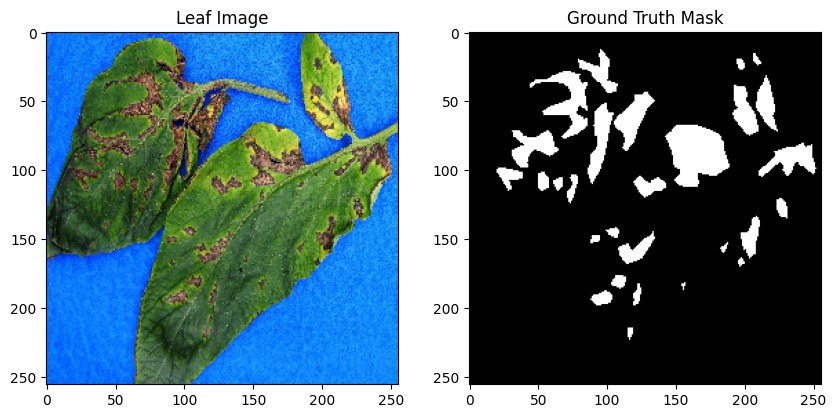

In [13]:
img, mask = val_dataset[10]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(
    img.permute(1,2,0).numpy()
)

plt.title("Leaf Image")

plt.subplot(1,2,2)

plt.imshow(
    mask.squeeze(),
    cmap='gray'
)

plt.title("Ground Truth Mask")

plt.show()

Disease Severity : 22.74%


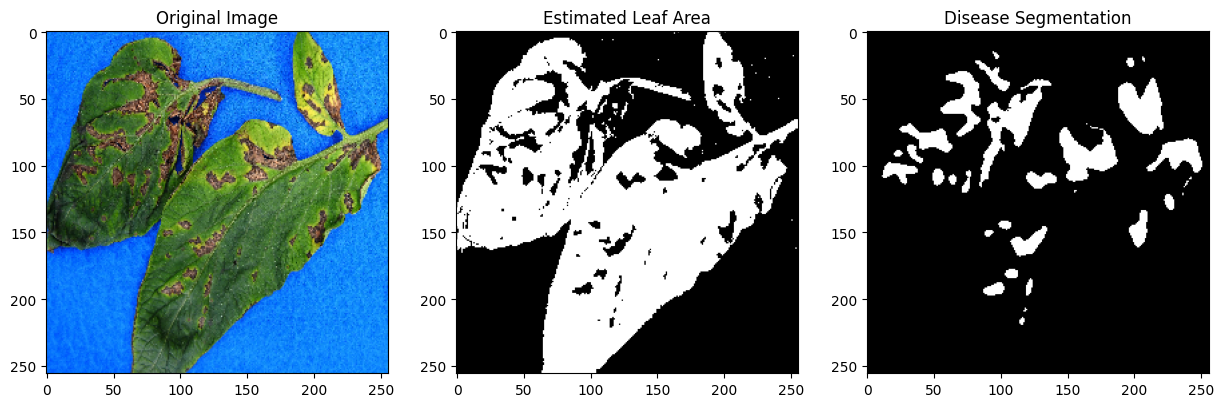

In [14]:
# =========================================================
# APPROXIMATE LEAF AREA
# =========================================================

img, mask = val_dataset[10]

image = img.permute(1,2,0).numpy()

# CONVERT TO HSV
hsv = cv2.cvtColor(
    (image * 255).astype(np.uint8),
    cv2.COLOR_RGB2HSV
)

# GREEN LEAF RANGE
lower_green = np.array([25, 20, 20])
upper_green = np.array([100, 255, 255])

# LEAF MASK
leaf_mask = cv2.inRange(
    hsv,
    lower_green,
    upper_green
)

leaf_mask = (leaf_mask > 0).astype(np.uint8)

# DISEASE MASK
with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

pred = pred.squeeze().cpu().numpy()

pred = (pred > 0.4).astype(np.uint8)

# PIXELS
leaf_pixels = np.sum(leaf_mask)

disease_pixels = np.sum(pred)

# SEVERITY
severity = (
    disease_pixels / leaf_pixels
) * 100

print(f"Disease Severity : {severity:.2f}%")

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(15,5))

# ORIGINAL
plt.subplot(1,3,1)

plt.imshow(image)

plt.title("Original Image")

# LEAF MASK
plt.subplot(1,3,2)

plt.imshow(
    leaf_mask,
    cmap='gray'
)

plt.title("Estimated Leaf Area")

# DISEASE
plt.subplot(1,3,3)

plt.imshow(
    pred,
    cmap='gray'
)

plt.title("Disease Segmentation")

plt.show()

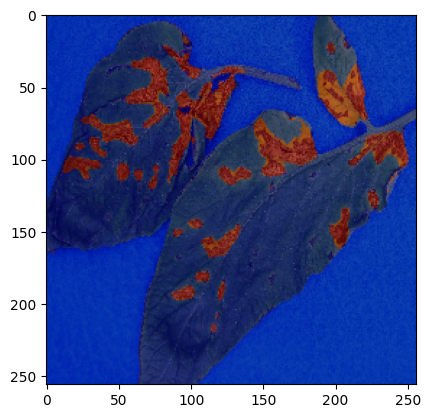

In [15]:
plt.imshow(image)

plt.imshow(
    pred,
    cmap='jet',
    alpha=0.6
)

In [16]:
torch.save(
    model,
    "/kaggle/working/full_leaf_model.pth"
)

print("✅ Full Model Saved!")

✅ Full Model Saved!


In [17]:
plt.savefig(
    "/kaggle/working/dice_loss_curve.png",
    bbox_inches='tight',
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(14,5))

# your plots here

plt.savefig(
    "/kaggle/working/training_curves.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 1400x500 with 0 Axes>

In [20]:
plt.savefig(
    "/kaggle/working/overlay_visualization.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [21]:
import os

save_dir = "/kaggle/working/final_predictions"

os.makedirs(save_dir, exist_ok=True)

In [22]:
# =========================================================
# ZIP ALL PREDICTIONS
# =========================================================

import shutil

shutil.make_archive(

    "/kaggle/working/final_predictions",

    'zip',

    "/kaggle/working/final_predictions"

)

print("✅ ZIP File Created!")

✅ ZIP File Created!


In [24]:
pred = cv2.GaussianBlur(
    pred,
    (15,15),
    0
)

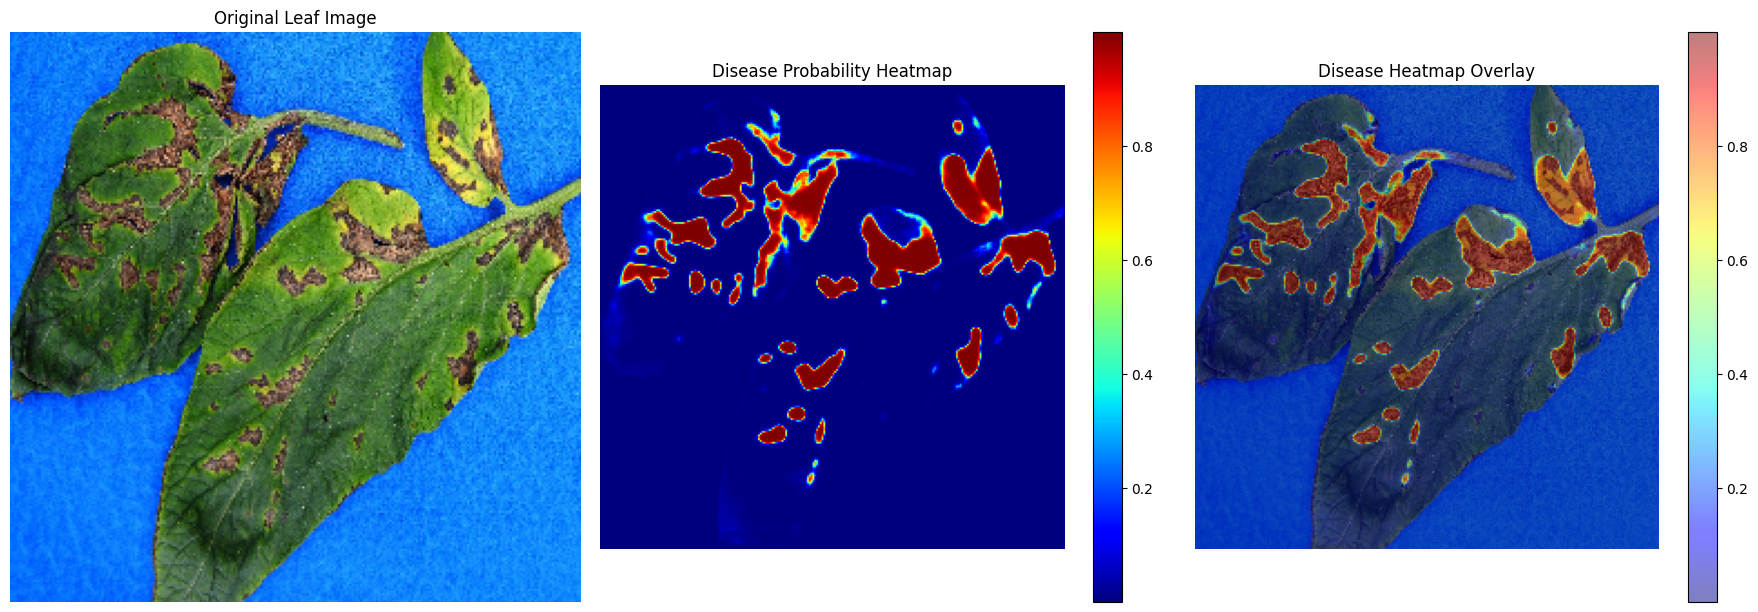

In [25]:
# =========================================================
# DISEASE HEATMAP VISUALIZATION
# =========================================================

model.eval()

# RANDOM SAMPLE
idx = 10

img, mask = val_dataset[idx]

with torch.no_grad():

    pred = model(
        img.unsqueeze(0).to(device)
    )

# PREDICTION
pred = pred.squeeze().cpu().numpy()

# IMAGE
image = img.permute(1,2,0).numpy()

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(18,6))

# ORIGINAL IMAGE
plt.subplot(1,3,1)

plt.imshow(image)

plt.title("Original Leaf Image")

plt.axis("off")


# RAW PROBABILITY HEATMAP
plt.subplot(1,3,2)

plt.imshow(
    pred,
    cmap='jet'
)

plt.colorbar()

plt.title("Disease Probability Heatmap")

plt.axis("off")


# OVERLAY HEATMAP
plt.subplot(1,3,3)

plt.imshow(image)

plt.imshow(
    pred,
    cmap='jet',
    alpha=0.5
)

plt.colorbar()

plt.title("Disease Heatmap Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()